# Predicción de pérdida de envíos (RNA)

Objetivo: entrenar una red neuronal que prediga `is_lost` para un envío **en el
momento de su creación, antes del despacho**. Esto condiciona todo el notebook:
cualquier columna que solo se conoce cuando el envío ya está en tránsito o
resuelto (un estado de seguimiento, una causa de pérdida, un monto de
reembolso) es fuga de información (*leakage*) y debe excluirse, aunque tenga
una correlación fuerte con la etiqueta. La sección de exploración existe para
encontrar y demostrar exactamente qué columnas caen en esa trampa en este
conjunto de datos, antes de que lleguen al modelo. Esto incluye una columna que
parece simple geografía (`LG_REGION`) pero que termina codificando la etiqueta
a través de una taxonomía inconsistente (sección 2), y una verificación general
de "auditoría de pureza" (sección 3) diseñada para detectar esa clase de
problema en cualquier variable categórica, no solo en la que se encontró aquí.

## 1. Configuración

Las constantes se definen una sola vez al inicio para que el resto del notebook
(y un futuro script de inferencia) las lea desde un único lugar. `TIME_LIMIT`
se lee de la variable de entorno `RNA_TIME_LIMIT` para que el mismo notebook
pueda ejecutarse como una prueba rápida (sin interfaz, con
`nbconvert --execute`) o como un entrenamiento real más largo sin modificar el
código.

In [31]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit

DATA_PATH = "../dataset.parquet"
LABEL = "is_lost"
GROUP = "SHIPMENT_ID"
RANDOM_STATE = 42
TIME_LIMIT = int(os.environ.get("RNA_TIME_LIMIT", 600))
MODEL_DIR = "../AutogluonModels/rna_shipment_loss"

# Paleta de Mercado Libre (los datos son de su operación), con un color por
# rol en todas las figuras. Azul y rojo forman el par divergente: "no perdido"
# y "perdido" deben leerse como opuestos. El amarillo de marca no codifica
# datos: sobre fondo blanco su contraste es de ~1,3:1, muy por debajo del 3:1
# mínimo para una marca gráfica, así que se usa solo como acento (la franja
# superior de cada figura).
ML_YELLOW = "#FFE600"
ML_BLUE = "#3483FA"
ML_RED = "#F23D4F"
ML_INK = "#333333"
ML_NEUTRAL = "#EDEDED"
ML_SURFACE = "#FFFFFF"

COLOR_NOT_LOST = ML_BLUE
COLOR_LOST = ML_RED
COLOR_SEQUENTIAL = ML_BLUE
COLOR_REFERENCE = ML_INK
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "mercadolibre_diverging", [ML_RED, ML_NEUTRAL, ML_BLUE]
)

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": ML_SURFACE,
        "axes.facecolor": ML_SURFACE,
        "axes.edgecolor": ML_NEUTRAL,
        "grid.color": ML_NEUTRAL,
        "text.color": ML_INK,
        "axes.labelcolor": ML_INK,
        "xtick.color": ML_INK,
        "ytick.color": ML_INK,
        "axes.titleweight": "bold",
    },
)


def finish_figure(fig, top=0.95):
    """Ajusta el diseño y agrega la franja amarilla de marca en el borde superior."""
    fig.tight_layout(rect=(0, 0, 1, top))
    fig.add_artist(
        Rectangle((0, 0.98), 1, 0.02, transform=fig.transFigure, facecolor=ML_YELLOW, edgecolor="none")
    )

## 2. Exploración de los datos crudos

Antes de tomar cualquier decisión de preprocesamiento, conviene observar el
conjunto de datos crudo: su forma, los tipos de columna, los valores faltantes,
el balance de la etiqueta y la evidencia que respalda las decisiones de
limpieza aplicadas en la sección 3 (fuga de la etiqueta, la inconsistencia
entre `DATEPARAMETER` y `date_status_0`, el sesgo de muestreo temporal, los
artefactos de valores faltantes y la granularidad de las filas a nivel de
artículo).

In [32]:
raw = pd.read_parquet(DATA_PATH)
# El tipo date32 de Parquet se carga como objetos `date` de Python (dtype
# object) en lugar de datetime64, así que la aritmética de fechas necesita una
# conversión explícita.
raw["DATEPARAMETER"] = pd.to_datetime(raw["DATEPARAMETER"])
print(f"forma: {raw.shape[0]:,} filas x {raw.shape[1]} columnas")
raw.dtypes.value_counts()

forma: 262,317 filas x 58 columnas


object            36
datetime64[us]    11
float64            6
int64              3
bool               1
datetime64[ns]     1
Name: count, dtype: int64

In [33]:
null_rate = raw.isna().mean().sort_values(ascending=False)
null_rate[null_rate > 0].to_frame("tasa_nulos")

,tasa_nulos
CANT_BULTOS,1.000000
FUE_AVION,0.947098
TIPO_BULKY,0.904585
status_1,0.768898
status_0,0.761285
L1_CAUSA_BPP,0.757225
F_CLASIFICATION_STD,0.757225
F_CLASIFICATION,0.757225
L2_CAUSA_BPP,0.757225
CAUSA_BPP,0.757225


In [34]:
label_counts = raw[LABEL].value_counts().sort_index()
label_rate = raw[LABEL].mean()
print(label_counts)
print(f"tasa de positivos: {label_rate:.3f}")

is_lost
0    198633
1     63684
Name: count, dtype: int64
tasa de positivos: 0.243


### Evidencia: fuga pura de la etiqueta (hecho 2)

Algunas columnas solo se completan cuando un envío ya fue clasificado como
perdido. Si una columna es no nula en el 100% de las filas perdidas y en el 0%
de las no perdidas, no puede ser una entrada legítima en el momento de la
creación: es una reformulación de la etiqueta.

In [35]:
LEAKAGE_COLUMNS = [
    "CAUSA_BPP",
    "L1_CAUSA_BPP",
    "L2_CAUSA_BPP",
    "DATE_BPP",
    "BPP_CASHOUT_USD",
    "CLASSIFICATION_LM",
    "SUBSTATUS_CLASIFICATION",
    "F_CLASIFICATION",
    "F_CLASIFICATION_STD",
]

# Proporción de valores no nulos por clase de la etiqueta.
leakage_evidence = raw.groupby(LABEL)[LEAKAGE_COLUMNS].apply(lambda g: g.notna().mean())
leakage_evidence

,CAUSA_BPP,L1_CAUSA_BPP,L2_CAUSA_BPP,DATE_BPP,BPP_CASHOUT_USD,CLASSIFICATION_LM,SUBSTATUS_CLASIFICATION,F_CLASIFICATION,F_CLASIFICATION_STD
is_lost,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Evidencia: `DATEPARAMETER` frente a `date_status_0` (hecho 4)

`DATEPARAMETER` parece una columna de fecha neutral, pero al compararla con
`date_status_0` (la marca de tiempo del primer estado, es decir, el inicio del
envío) se observa que codifica la etiqueta de forma silenciosa: es idéntica a
`date_status_0` en las filas no perdidas y varios días posterior en las filas
perdidas. `date_status_0` es la marca de tiempo consistente del inicio del
envío; `DATEPARAMETER` debe descartarse.

In [36]:
date_gap_days = (raw["DATEPARAMETER"] - raw["date_status_0"].dt.normalize()).dt.days
gap_by_label = date_gap_days.groupby(raw[LABEL]).agg(media="mean", mediana="median", maximo="max")
gap_by_label

,media,mediana,maximo
is_lost,,,
0,0.00000,0.0,0.0
1,8.79741,7.0,95.0


### Evidencia: sesgo de muestreo temporal (hecho 5)

Al agrupar por mes de `DATEPARAMETER`, la tasa de pérdida oscila de forma
abrupta y cae exactamente a cero en los meses más recientes. No se trata de un
efecto estacional real: significa que la etiqueta "perdido" todavía no ha
madurado para los envíos recientes (un envío solo se marca como perdido un
tiempo después de su creación), por lo que los meses recientes parecen seguros
sin serlo. Todo mes en el que solo esté presente una clase debe excluirse del
entrenamiento; de lo contrario, el modelo aprendería el artefacto de extracción
en lugar del riesgo real.

In [37]:
month_of_dateparameter = raw["DATEPARAMETER"].dt.to_period("M")
lost_rate_by_month = raw.groupby(month_of_dateparameter)[LABEL].agg(tasa_perdida="mean", filas="count")
lost_rate_by_month

,tasa_perdida,filas
DATEPARAMETER,,
2025-09,0.098140,13226
2025-10,0.356325,19210
2025-11,0.391343,28139
2025-12,0.498999,39970
2026-01,0.381887,24104
2026-02,0.322367,18997
2026-03,0.365093,22849
2026-04,0.058131,15706
2026-05,0.000000,17699


### Evidencia: artefactos de valores faltantes (hecho 6)

Las filas a las que les faltan campos numéricos centrales (peso, dimensiones,
valor, cantidad de artículos) o `date_status_0` están casi todas perdidas. Es,
de nuevo, un artefacto de cómo se extrajeron las dos clases, no una relación
real entre "el envío no tiene peso registrado" y "el envío se pierde". Estas
filas se eliminan en lugar de imputarse.

In [38]:
MISSINGNESS_ARTIFACT_COLUMNS = ["PESO_TOTAL_KG", "DIM_MAX_CM", "VALOR_TOTAL_USD", "CANTIDAD_ITEMS"]

for column in MISSINGNESS_ARTIFACT_COLUMNS + ["date_status_0"]:
    is_null = raw[column].isna()
    print(f"{column}: {is_null.mean():.4%} nulos, tasa de pérdida cuando es nulo = {raw.loc[is_null, LABEL].mean():.3f}")

PESO_TOTAL_KG: 0.4506% nulos, tasa de pérdida cuando es nulo = 0.998
DIM_MAX_CM: 0.4506% nulos, tasa de pérdida cuando es nulo = 0.998
VALOR_TOTAL_USD: 0.4498% nulos, tasa de pérdida cuando es nulo = 1.000
CANTIDAD_ITEMS: 0.4498% nulos, tasa de pérdida cuando es nulo = 1.000
date_status_0: 0.4060% nulos, tasa de pérdida cuando es nulo = 1.000


### Evidencia: `LG_REGION` usa dos taxonomías

`LG_REGION` parece una variable legítima en el momento de la creación (la
instalación y la región de un envío se conocen cuando se crea), pero su tasa de
pérdida por valor es sospechosamente bimodal. La razón: la misma instalación se
exporta con nombres de región distintos según la clase de la fila, de modo que
el nombre de la región termina codificando la etiqueta. `SHP_LG_FACILITY_ID` no
tiene este problema y se conserva como la variable geográfica.

In [39]:
region_stats = raw.groupby("LG_REGION", observed=True)[LABEL].agg(["mean", "count"])
pure_regions = region_stats[(region_stats["mean"] == 0) | (region_stats["mean"] == 1)]
pure_row_share = pure_regions["count"].sum() / len(raw)
print(f"valores de LG_REGION: {len(region_stats)}, puros (exactamente 0% o 100% de pérdida): {len(pure_regions)}")
print(f"proporción de filas en un valor de región puro: {pure_row_share:.1%}")
print("puros con 0% de pérdida:", sorted(pure_regions.loc[pure_regions['mean'] == 0].index.tolist()))
print("puros con 100% de pérdida:", sorted(pure_regions.loc[pure_regions['mean'] == 1].index.tolist()))

valores de LG_REGION: 25, puros (exactamente 0% o 100% de pérdida): 17
proporción de filas en un valor de región puro: 52.6%
puros con 0% de pérdida: ['Central', 'Cluster Puebla', 'Epicentro', 'Golfo', 'Istmo', 'Jalisco', 'Levante', 'MS Sureste', 'Norcentral', 'Pacifico', 'Poniente']
puros con 100% de pérdida: ['Bajio', 'Istmo-Golfo', 'Metro Central', 'Metro Megas', 'Metro Poniente', 'Occidente']


In [40]:
facility_region_counts = raw.groupby("SHP_LG_FACILITY_ID", observed=True)["LG_REGION"].nunique()
multi_region_facilities = facility_region_counts[facility_region_counts > 1]
print(f"instalaciones: {facility_region_counts.shape[0]}, asociadas a más de un nombre de región: {len(multi_region_facilities)}")

facility_region_breakdown = (
    raw[raw["SHP_LG_FACILITY_ID"].isin(multi_region_facilities.index)]
    .groupby(["SHP_LG_FACILITY_ID", "LG_REGION"], observed=True)[LABEL]
    .agg(tasa_perdida="mean", filas="count")
)
top_multi_region_facilities = (
    facility_region_breakdown.groupby(level=0)["filas"].sum().sort_values(ascending=False).head(5).index
)
facility_region_breakdown.loc[top_multi_region_facilities]

instalaciones: 104, asociadas a más de un nombre de región: 53


tasa_perdida  filas
SHP_LG_FACILITY_ID LG_REGION                         
SMX11              Metro Megas             1.0   3682
                   Metro Norte             0.0   3944
SGD2               Centro                  1.0   2546
                   Jalisco                 0.0   5006
SQR1               Bajio                   1.0   2922
                   Epicentro               0.0   4273
SMX9               Centro                  0.0   5339
                   Metro Central           1.0   1683
SLE1               Bajio                   1.0   2974
                   Epicentro               0.0   3830

### Evidencia: granularidad a nivel de artículo (hecho 9)

Una fila es un artículo de un envío, no un envío: algunos `SHIPMENT_ID`
aparecen varias veces. La etiqueta nunca difiere dentro de un mismo envío, así
que es seguro mantener la granularidad por artículo, pero toda partición debe
agrupar por `SHIPMENT_ID`; de lo contrario, el mismo envío podría filtrarse
entre entrenamiento, validación y prueba.

In [41]:
shipments_per_row_count = raw.groupby(GROUP).size()
multi_row_shipments = shipments_per_row_count[shipments_per_row_count > 1]
print(f"envíos con más de una fila: {len(multi_row_shipments):,}")
print(f"filas que pertenecen a un envío con varias filas: {multi_row_shipments.sum():,}")

label_conflicts = raw.groupby(GROUP)[LABEL].nunique()
print(f"envíos con etiquetas contradictorias entre filas: {(label_conflicts > 1).sum()}")

envíos con más de una fila: 8,837
filas que pertenecen a un envío con varias filas: 25,077
envíos con etiquetas contradictorias entre filas: 0


## 3. Limpieza y preprocesamiento

`preprocess` es una sola función para que la misma lógica pueda trasladarse más
adelante a un script de inferencia sin duplicar decisiones. Solo hace lo que
AutoGluon no puede hacer por nosotros: eliminar la fuga de información,
eliminar los artefactos de muestreo y corregir la granularidad. **No** escala,
imputa ni aplica codificación *one-hot*: el `TabularPredictor` de AutoGluon
gestiona internamente los valores faltantes, la codificación y el escalado,
tanto para los modelos de árboles como para las redes neuronales que puede
entrenar, por lo que hacerlo a mano solo duplicaría esa lógica o entraría en
conflicto con ella.

Las listas de columnas que siguen sirven también como documentación: cada
columna cruda queda clasificada como variable conservada, etiqueta, clave de
grupo o un motivo de descarte con nombre explícito, incluida
`TAXONOMY_ARTIFACT_COLUMNS`, agregada tras el hallazgo sobre `LG_REGION` de la
sección 2.

In [42]:
TIMELINE_COLUMNS = (
    [f"status_{i}" for i in range(11)] + [f"date_status_{i}" for i in range(1, 11)]
)
DATE_LEAK_COLUMNS = ["DATEPARAMETER"]
CONSTANT_COLUMNS = ["PAIS", "TOTALGMV", "CANT_BULTOS"]
REDUNDANT_COLUMNS = ["LG_FACILITY_NAME", "ORD_CATEGORY_ID_L1"]
IDENTIFIER_COLUMNS = ["SHP_SHIPMENT_ID", "ITE_ITEM_ID", "ITE_ITEM_DESC"]
ROUTE_COLUMNS = ["FUE_AVION"]
PROVENANCE_COLUMNS = ["source_file", "batch_num"]
# LG_REGION se exporta con nombres distintos para la misma instalación según
# la clase de la fila (ver la evidencia de la sección 2), así que codifica la
# etiqueta y no la geografía real; SHP_LG_FACILITY_ID aporta esa señal de
# forma segura.
TAXONOMY_ARTIFACT_COLUMNS = ["LG_REGION"]
DATE_COLUMN = "date_status_0"

CATEGORICAL_FEATURES = [
    "PICKING_TYPE",
    "SHP_LG_FACILITY_ID",
    "DOM_DOMAIN_ID",
    "ORD_CATEGORY_NAME_L1",
    "BRAND_NAME",
    "TIPO_BULKY",
]
NUMERIC_FEATURES = [
    "PESO_TOTAL_KG",
    "DIM_MAX_CM",
    "VALOR_TOTAL_USD",
    "CANTIDAD_ITEMS",
    "RATIO_SVC_MES_ANTERIOR",
    "ES_BULKY",
]
DERIVED_FEATURES = ["day_of_week"]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES + DERIVED_FEATURES
print(f"cantidad de variables: {len(FEATURE_COLUMNS)}")

DROPPED_COLUMNS = (
    LEAKAGE_COLUMNS
    + TIMELINE_COLUMNS
    + DATE_LEAK_COLUMNS
    + CONSTANT_COLUMNS
    + REDUNDANT_COLUMNS
    + IDENTIFIER_COLUMNS
    + ROUTE_COLUMNS
    + PROVENANCE_COLUMNS
    + TAXONOMY_ARTIFACT_COLUMNS
)

# Toda columna cruda debe quedar clasificada: variable conservada, etiqueta,
# clave de grupo, la fecha usada para derivar day_of_week o un motivo de
# descarte con nombre.
accounted_for = set(CATEGORICAL_FEATURES + NUMERIC_FEATURES) | set(DROPPED_COLUMNS) | {LABEL, GROUP, DATE_COLUMN}
assert accounted_for == set(raw.columns), sorted(set(raw.columns) - accounted_for)

cantidad de variables: 13


In [43]:
DAY_NAMES = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]


def preprocess(raw: pd.DataFrame) -> pd.DataFrame:
    """Convierte la exportación cruda en una tabla lista para el modelo: variables + LABEL + GROUP.

    Las columnas con fuga de información, la línea de tiempo posterior a la
    creación y los datos administrativos de la exportación se descartan por
    completo. Los filtros de filas eliminan las que solo existen por la forma
    en que se extrajeron las dos clases de la etiqueta (artefactos de valores
    faltantes, meses en los que la etiqueta aún no ha madurado), no porque
    sean envíos inválidos.
    """
    frame = raw.copy()
    print(f"filas antes de cualquier filtro: {len(frame):,}")

    # Filas con artefactos de valores faltantes (hecho 6): estos nulos marcan
    # filas traídas por la extracción, no mediciones realmente ausentes.
    artifact_null = frame[MISSINGNESS_ARTIFACT_COLUMNS + [DATE_COLUMN]].isna().any(axis=1)
    frame = frame.loc[~artifact_null]
    print(f"filas tras eliminar los artefactos de valores faltantes: {len(frame):,}")

    # Ventana de madurez de la etiqueta (hecho 5): se conservan solo los meses
    # de date_status_0 en los que se observan ambas clases, calculados a
    # partir de los datos y no fijados a mano.
    month = frame[DATE_COLUMN].dt.to_period("M")
    classes_per_month = frame.groupby(month)[LABEL].nunique()
    valid_months = classes_per_month[classes_per_month == 2].index
    frame = frame.loc[month.isin(valid_months)]
    print(f"meses válidos (ambas clases presentes): {[str(m) for m in valid_months]}")
    print(f"filas tras restringir a los meses con ambas clases: {len(frame):,}")

    # Un TIPO_BULKY nulo significa "no voluminoso", no información faltante.
    frame["TIPO_BULKY"] = frame["TIPO_BULKY"].fillna("NONE")

    # Única variable derivada de la fecha permitida: el día de la semana (sin
    # fecha ni hora absolutas, ver hecho 5: una fecha absoluta solo volvería a
    # codificar el sesgo de muestreo). Los nombres se asignan desde DAY_NAMES
    # para no depender de la configuración regional del sistema.
    frame["day_of_week"] = pd.Categorical(
        frame[DATE_COLUMN].dt.dayofweek.map(dict(enumerate(DAY_NAMES))),
        categories=DAY_NAMES,
        ordered=True,
    )

    # Las categóricas con forma de identificador deben seguir siendo
    # texto/categoría, nunca numéricas.
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("category")

    return frame[FEATURE_COLUMNS + [LABEL, GROUP]]


clean = preprocess(raw)
clean.shape

filas antes de cualquier filtro: 262,317
filas tras eliminar los artefactos de valores faltantes: 260,104
meses válidos (ambas clases presentes): ['2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
filas tras restringir a los meses con ambas clases: 179,990


(179990, 15)

### Auditoría de pureza: cómo detectar fugas de taxonomía como `LG_REGION`

`LG_REGION` solo se detectó al notar manualmente una tasa de pérdida
sospechosamente bimodal. Esta verificación generaliza ese hallazgo: para cada
variable categórica conservada en el conjunto final, ¿qué proporción de sus
filas cae en un valor cuya propia tasa de pérdida es extrema (<=2% o >=98%,
con al menos 200 filas para que la estimación no sea solo ruido de muestras
pequeñas)? Una proporción alta es la misma señal de alerta que dio `LG_REGION`
y merece la misma investigación antes de confiar en la variable.

In [44]:
def categorical_purity_audit(frame, columns, label, min_rows=200, low=0.02, high=0.98):
    rows = []
    for column in columns:
        stats = frame.groupby(column, observed=True)[label].agg(["mean", "count"])
        pure = stats[(stats["count"] >= min_rows) & ((stats["mean"] <= low) | (stats["mean"] >= high))]
        rows.append({
            "variable": column,
            "valores": len(stats),
            "valores_puros": len(pure),
            "proporcion_filas_puras": pure["count"].sum() / len(frame),
        })
    return pd.DataFrame(rows).set_index("variable").sort_values("proporcion_filas_puras", ascending=False)


purity_audit = categorical_purity_audit(clean, CATEGORICAL_FEATURES, LABEL)
purity_audit

,valores,valores_puros,proporcion_filas_puras
variable,,,
DOM_DOMAIN_ID,2865,6,0.013784
SHP_LG_FACILITY_ID,96,4,0.009873
PICKING_TYPE,4,1,0.001939
ORD_CATEGORY_NAME_L1,70,0,0.000000
BRAND_NAME,28715,0,0.000000
TIPO_BULKY,3,0,0.000000


## 4. Visualización de los datos limpios

Las figuras usan una paleta única en todo el notebook, tomada de la identidad
visual de Mercado Libre, de donde provienen los datos: azul (`#3483FA`) para
"no perdido", rojo (`#F23D4F`) para "perdido" (un par divergente, ya que las
dos clases deben leerse como opuestas) y el mismo azul para las barras de
magnitud simple. El par azul/rojo se validó para daltonismo (protanopía y
deuteranopía) y para contraste sobre fondo blanco. El amarillo de marca
(`#FFE600`) no codifica datos porque su contraste sobre blanco es demasiado
bajo para una marca gráfica; se usa como acento en la franja superior de cada
figura. Las líneas de referencia van en gris oscuro neutro. Las categorías se
ordenan por el valor que se muestra, no por el orden del conjunto de datos.

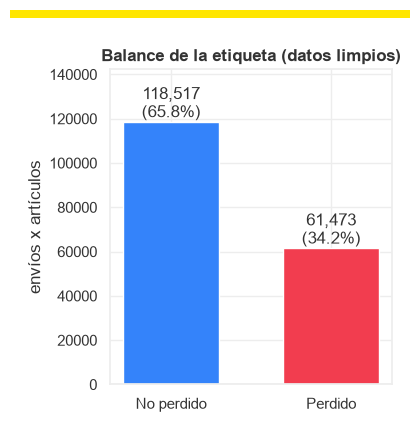

In [45]:
fig, ax = plt.subplots(figsize=(4, 4.2))
counts = clean[LABEL].value_counts().sort_index()
ax.bar(["No perdido", "Perdido"], counts.values, color=[COLOR_NOT_LOST, COLOR_LOST], width=0.6)
ax.set_title("Balance de la etiqueta (datos limpios)")
ax.set_ylabel("envíos x artículos")
ax.set_ylim(0, counts.max() * 1.2)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v / counts.sum():.1%})", ha="center", va="bottom")
finish_figure(fig)

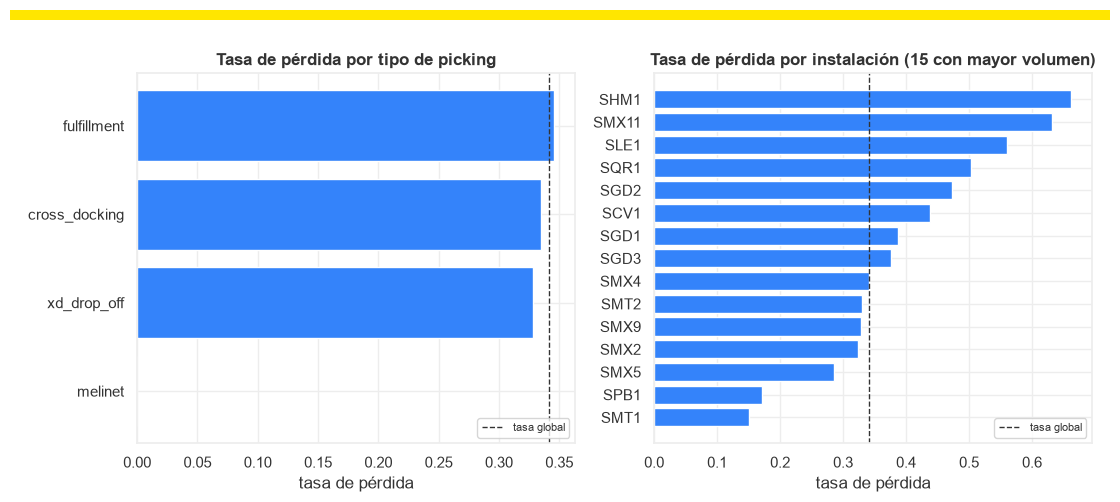

In [46]:
def lost_rate_bar(ax, series, title, top_n=None):
    rate = clean.groupby(series, observed=True)[LABEL].mean().sort_values(ascending=False)
    if top_n:
        rate = rate.head(top_n)
    ax.barh(rate.index.astype(str)[::-1], rate.values[::-1], color=COLOR_SEQUENTIAL)
    ax.set_title(title)
    ax.set_xlabel("tasa de pérdida")
    ax.axvline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
    ax.legend(loc="lower right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
lost_rate_bar(axes[0], clean["PICKING_TYPE"], "Tasa de pérdida por tipo de picking")

top_facilities = clean["SHP_LG_FACILITY_ID"].value_counts().head(15).index
facility_rate = (
    clean[clean["SHP_LG_FACILITY_ID"].isin(top_facilities)]
    .groupby("SHP_LG_FACILITY_ID", observed=True)[LABEL]
    .mean()
    .sort_values(ascending=False)
)
axes[1].barh(facility_rate.index.astype(str)[::-1], facility_rate.values[::-1], color=COLOR_SEQUENTIAL)
axes[1].axvline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
axes[1].set_title("Tasa de pérdida por instalación (15 con mayor volumen)")
axes[1].set_xlabel("tasa de pérdida")
axes[1].legend(loc="lower right", fontsize=8)
finish_figure(fig)

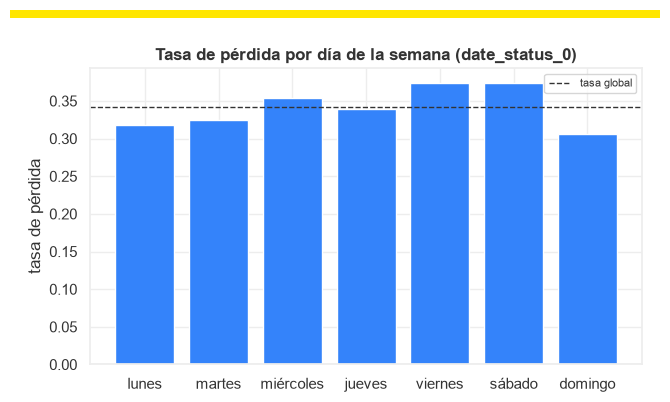

In [47]:
fig, ax = plt.subplots(figsize=(6.5, 4))
rate_by_dow = clean.groupby("day_of_week", observed=True)[LABEL].mean()
ax.bar(rate_by_dow.index.astype(str), rate_by_dow.values, color=COLOR_SEQUENTIAL)
ax.axhline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
ax.set_title("Tasa de pérdida por día de la semana (date_status_0)")
ax.set_ylabel("tasa de pérdida")
ax.legend(fontsize=8)
finish_figure(fig)

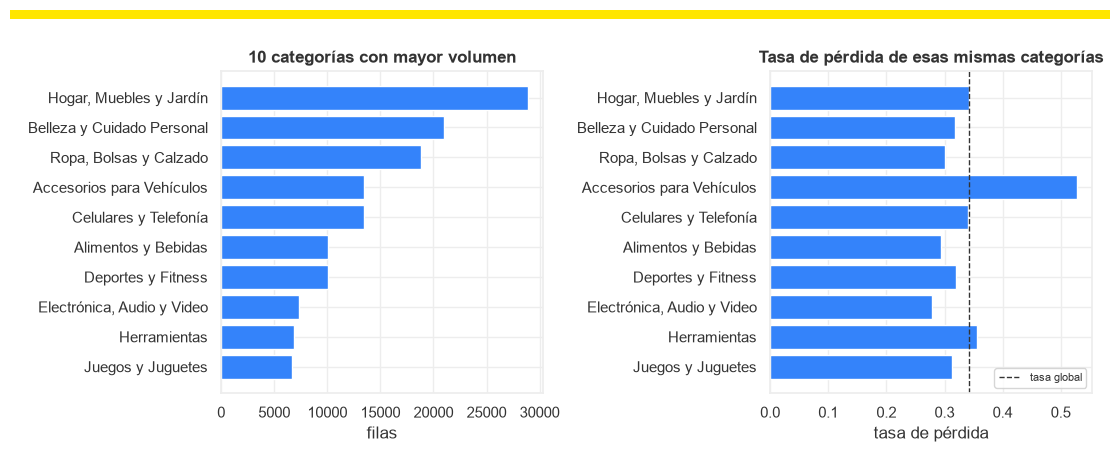

In [48]:
top_categories = clean["ORD_CATEGORY_NAME_L1"].value_counts().head(10)
rate_top_categories = clean.groupby("ORD_CATEGORY_NAME_L1", observed=True)[LABEL].mean().loc[top_categories.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(top_categories.index.astype(str)[::-1], top_categories.values[::-1], color=COLOR_SEQUENTIAL)
axes[0].set_title("10 categorías con mayor volumen")
axes[0].set_xlabel("filas")
axes[1].barh(rate_top_categories.index.astype(str)[::-1], rate_top_categories.values[::-1], color=COLOR_SEQUENTIAL)
axes[1].axvline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
axes[1].set_title("Tasa de pérdida de esas mismas categorías")
axes[1].set_xlabel("tasa de pérdida")
axes[1].legend(loc="lower right", fontsize=8)
finish_figure(fig)

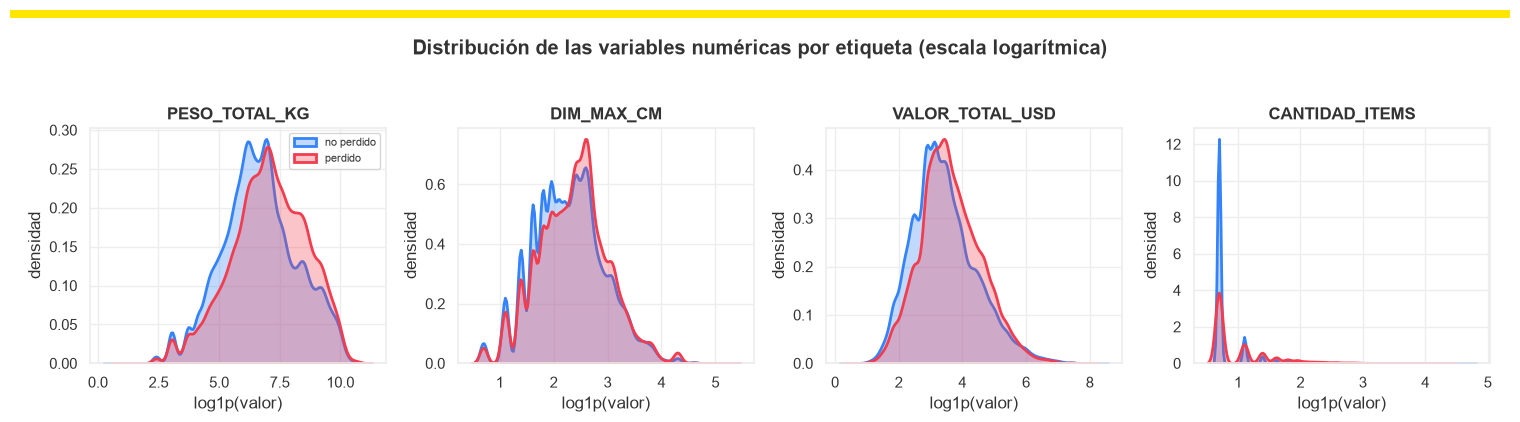

In [49]:
numeric_to_plot = ["PESO_TOTAL_KG", "DIM_MAX_CM", "VALOR_TOTAL_USD", "CANTIDAD_ITEMS"]
fig, axes = plt.subplots(1, len(numeric_to_plot), figsize=(15, 4.2))
for ax, column in zip(axes, numeric_to_plot):
    for label_value, color, name in [(0, COLOR_NOT_LOST, "no perdido"), (1, COLOR_LOST, "perdido")]:
        values = clean.loc[clean[LABEL] == label_value, column]
        values = values[values > 0]
        sns.kdeplot(np.log1p(values), ax=ax, color=color, label=name, fill=True, alpha=0.3, linewidth=2)
    ax.set_title(column)
    ax.set_xlabel("log1p(valor)")
    ax.set_ylabel("densidad")
axes[0].legend(fontsize=8)
fig.suptitle("Distribución de las variables numéricas por etiqueta (escala logarítmica)", y=0.93, fontweight="bold")
finish_figure(fig, top=0.9)

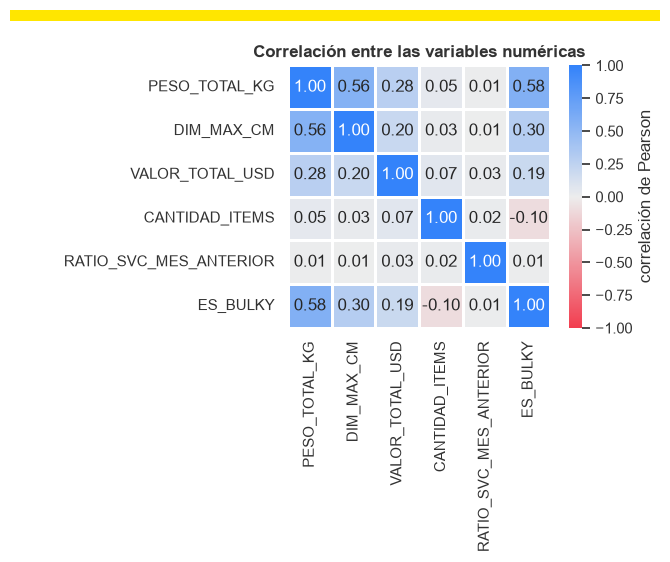

In [50]:
numeric_corr_columns = NUMERIC_FEATURES
correlation = clean[numeric_corr_columns].astype(float).corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    correlation,
    ax=ax,
    cmap=DIVERGING_CMAP,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=2,
    linecolor=ML_SURFACE,
    cbar_kws={"label": "correlación de Pearson"},
)
ax.set_title("Correlación entre las variables numéricas")
finish_figure(fig)

## 5. Partición entrenamiento / validación / prueba por grupos

Una partición por filas permitiría que el mismo envío apareciera en ambos lados
(hecho 9), lo que filtraría información a través de los atributos compartidos a
nivel de artículo. `GroupShuffleSplit` sobre `SHIPMENT_ID` garantiza que cada
envío quede completo en un solo lado. La partición se hace en dos pasos para
llegar aproximadamente a 70/15/15: primero se separa el conjunto de prueba
(15%) y luego el resto se divide en entrenamiento y validación.

In [51]:
splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(splitter_test.split(clean, groups=clean[GROUP]))
train_val, test = clean.iloc[train_val_idx], clean.iloc[test_idx]

# La validación debe ser ~15% del total ORIGINAL, es decir, ~0.15 / 0.85 del resto.
splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter_val.split(train_val, groups=train_val[GROUP]))
train, val = train_val.iloc[train_idx], train_val.iloc[val_idx]

train_groups, val_groups, test_groups = set(train[GROUP]), set(val[GROUP]), set(test[GROUP])
assert not (train_groups & val_groups)
assert not (train_groups & test_groups)
assert not (val_groups & test_groups)

for name, part in [("entrenamiento", train), ("validación", val), ("prueba", test)]:
    print(f"{name}: {len(part):,} filas, {part[GROUP].nunique():,} envíos, tasa de positivos = {part[LABEL].mean():.3f}")

train = train.drop(columns=GROUP)
val = val.drop(columns=GROUP)
test = test.drop(columns=GROUP)

entrenamiento: 126,027 filas, 114,775 envíos, tasa de positivos = 0.341
validación: 26,945 filas, 24,595 envíos, tasa de positivos = 0.344
prueba: 27,018 filas, 24,595 envíos, tasa de positivos = 0.343


## 6. Entrenamiento

`TabularPredictor` es el punto de entrada de AutoML de AutoGluon: por defecto
entrena y combina varias familias de modelos (árboles con *gradient boosting*,
bosques aleatorios, redes neuronales, etc.). Aquí el objetivo es
específicamente una red neuronal artificial (RNA), así que `hyperparameters` se
restringe a los dos motores de redes neuronales de AutoGluon: `NN_TORCH` (un
MLP tabular en PyTorch) y `FASTAI` (el modelo tabular de fastai). No se entrena
ningún árbol.

Se usa `eval_metric="average_precision"` en lugar de la exactitud
(*accuracy*): la etiqueta está desbalanceada (~34% de positivos tras la
limpieza, ~24% en los datos crudos), de modo que un modelo que siempre
predijera "no perdido" ya obtendría alrededor de 66% de exactitud sin servir
para nada. La precisión
promedio (el área bajo la curva de precisión-exhaustividad) premia ordenar bien
la clase positiva, que es lo que realmente importa en una puntuación de riesgo.

`tuning_data=val` pasa de forma explícita la partición de validación por
grupos, en lugar de dejar que AutoGluon separe su propia reserva interna a
partir de `train`: esa reserva interna se dividiría por filas y no por
`SHIPMENT_ID`, lo que reintroduciría la fuga que la sección 5 busca evitar.

In [52]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(
    label=LABEL,
    problem_type="binary",
    eval_metric="average_precision",
    path=MODEL_DIR,
).fit(
    train,
    tuning_data=val,
    hyperparameters={"NN_TORCH": {}, "FASTAI": {}},
    time_limit=TIME_LIMIT,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.12.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.6.0: Fri Jul 31 19:19:08 PDT 2026; root:xnu-12377.161.14~5/RELEASE_ARM64_T6050
CPU Count:          15
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       22.10 GB / 48.00 GB (46.0%)
Disk Space Avail:   747.60 GB / 926.30 GB (80.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : Use this if you have a GPU. The go-to preset for best results, and the one to use for benchmark comparisons. N

## 7. Evaluación sobre el conjunto de prueba reservado

`test` nunca se vio durante el entrenamiento ni durante la selección de modelos
(quedó fuera tanto de `train` como del `tuning_data` usado para la detención
temprana y la selección de modelos), y sus envíos son disjuntos de los de las
otras dos particiones.

In [53]:
predictor.leaderboard(test, display=True)

                 model  score_test  score_val        eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2    0.799453   0.795762  average_precision        0.162519       0.148649  84.137917                 0.000708                0.002311           0.111894            2       True          3
1      NeuralNetFastAI    0.784118   0.778334  average_precision        0.102780       0.087163  53.142399                 0.102780                0.087163          53.142399            1       True          1
2       NeuralNetTorch    0.746954   0.744730  average_precision        0.059031       0.059175  30.883624                 0.059031                0.059175          30.883624            1       True          2


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.799453,0.795762,average_precision,0.162519,0.148649,84.137917,0.000708,0.002311,0.111894,2,True,3
1,NeuralNetFastAI,0.784118,0.778334,average_precision,0.102780,0.087163,53.142399,0.102780,0.087163,53.142399,1,True,1
2,NeuralNetTorch,0.746954,0.744730,average_precision,0.059031,0.059175,30.883624,0.059031,0.059175,30.883624,1,True,2


In [54]:
predictor.evaluate(test, silent=True)

{'average_precision': 0.7994529841789602,
 'accuracy': 0.8091642608631283,
 'balanced_accuracy': np.float64(0.7484042813619509),
 'mcc': 0.5618899202700554,
 'roc_auc': np.float64(0.8484278700242041),
 'f1': 0.666105426758192,
 'precision': 0.83354943273906,
 'recall': 0.5546807592752373}

In [55]:
proba = predictor.predict_proba(test, as_multiclass=False)
y_true = test[LABEL].to_numpy()

roc_auc = roc_auc_score(y_true, proba)
avg_precision = average_precision_score(y_true, proba)
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precisión promedio: {avg_precision:.4f}")

ROC AUC: 0.8484
Precisión promedio: 0.7995


In [56]:
y_pred = (proba >= 0.5).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["no perdido", "perdido"]))

[[16719  1027]
 [ 4129  5143]]
              precision    recall  f1-score   support

  no perdido       0.80      0.94      0.87     17746
     perdido       0.83      0.55      0.67      9272

    accuracy                           0.81     27018
   macro avg       0.82      0.75      0.77     27018
weighted avg       0.81      0.81      0.80     27018



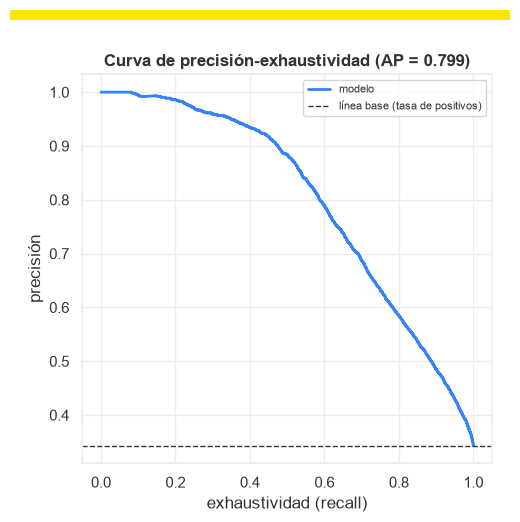

In [57]:
precision, recall, _ = precision_recall_curve(y_true, proba)
fig, ax = plt.subplots(figsize=(5, 5.2))
ax.plot(recall, precision, color=ML_BLUE, linewidth=2, label="modelo")
ax.axhline(y_true.mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="línea base (tasa de positivos)")
ax.set_xlabel("exhaustividad (recall)")
ax.set_ylabel("precisión")
ax.set_title(f"Curva de precisión-exhaustividad (AP = {avg_precision:.3f})")
ax.legend(fontsize=8)
finish_figure(fig)

In [58]:
predictor.feature_importance(test.sample(n=min(5000, len(test)), random_state=RANDOM_STATE), subsample_size=5000, num_shuffle_sets=3)

Computing feature importance via permutation shuffling for 13 features using 5000 rows with 3 shuffle sets...
	2.35s	= Expected runtime (0.78s per shuffle set)
	1.17s	= Actual runtime (Completed 3 of 3 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
DOM_DOMAIN_ID,0.179629,0.005189,0.000139,3,0.209366,0.149893
CANTIDAD_ITEMS,0.128479,0.003445,0.000120,3,0.148218,0.108741
SHP_LG_FACILITY_ID,0.102912,0.002423,0.000092,3,0.116794,0.089030
PESO_TOTAL_KG,0.045889,0.001841,0.000268,3,0.056441,0.035338
ORD_CATEGORY_NAME_L1,0.027603,0.002055,0.000921,3,0.039378,0.015828
PICKING_TYPE,0.017014,0.001875,0.002012,3,0.027758,0.006271
BRAND_NAME,0.015573,0.001442,0.001423,3,0.023836,0.007311
RATIO_SVC_MES_ANTERIOR,0.006745,0.000509,0.000946,3,0.009661,0.003829
day_of_week,0.005769,0.001088,0.005821,3,0.012002,-0.000464
DIM_MAX_CM,0.004237,0.001060,0.010113,3,0.010310,-0.001836


## 8. Limitaciones y próximos pasos

- La proporción de clases tras la limpieza sigue siendo producto de la ventana
  de extracción que se conservó, no una prevalencia medida en el mundo real:
  las probabilidades predichas deben leerse como una señal para ordenar por
  riesgo, no como una probabilidad de pérdida calibrada.
- La partición entrenamiento/validación/prueba es aleatoria por grupos, no
  temporal, así que no evalúa cómo se comportaría el modelo con envíos
  realmente futuros. Una partición basada en el tiempo sería una validación más
  sólida de su preparación para producción.
- Las filas están a nivel de artículo, no de envío; un envío con muchos
  artículos aporta muchas filas correlacionadas a las estadísticas de una
  partición.
- `preprocess` está escrita como una única función reutilizable precisamente
  para poder trasladarla a un script de inferencia independiente sin reescribir
  la lógica de limpieza.
- `LG_REGION` se descartó por completo en lugar de repararse en esta pasada. Un
  mapeo instalación -> región canónica (construido de forma independiente de
  la etiqueta, por ejemplo a partir de una única fuente confiable por
  instalación) podría recuperar la región como una variable segura más
  adelante; mientras tanto, `SHP_LG_FACILITY_ID` ya aporta la señal
  geográfica.